# Task 2 — Credit Risk Prediction
### Binary Classification · Logistic Regression · Decision Tree · Model Evaluation

**Objective:** Predict whether a loan applicant is likely to default on a loan.

**Dataset:** Loan Prediction Dataset — Kaggle

**Skills Covered:**
- Data cleaning and handling missing values
- Exploratory Data Analysis (EDA)
- Binary classification using Logistic Regression and Decision Tree
- Model evaluation using accuracy and confusion matrix


## Step 1 — Install Required Libraries

We install all libraries needed for this project in one command.
Run this cell once, then you can skip it on future runs.

**Libraries used:**
- `pandas` — data manipulation and cleaning
- `numpy` — numerical operations
- `matplotlib` + `seaborn` — data visualization
- `scikit-learn` — machine learning models and evaluation

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Import Libraries

All imports are gathered at the top for a clean, readable structure.
We also suppress warnings and set a consistent plot theme throughout the notebook.

**Key imports:**
- `LabelEncoder` — converts text categories to numbers for the model
- `train_test_split` — splits data into training and testing sets
- `LogisticRegression`, `DecisionTreeClassifier` — our two classification models
- `confusion_matrix`, `accuracy_score`, `classification_report` — evaluation tools

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 3 — Load the Dataset

We load the Loan Prediction dataset downloaded from Kaggle.
The first thing we do is look at the raw shape and preview the first few rows to understand the structure.

**What to check:**
- How many rows and columns exist
- What each column represents
- What the target column (`Loan_Status`) looks like — `Y` means approved, `N` means rejected (default risk)

In [3]:
# Load dataset — make sure train.csv is in the same folder as this notebook
df = pd.read_csv('train.csv')

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 Rows:')
df.head()

Shape: (614, 13)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 Rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 4 — Dataset Overview and Data Types

Before cleaning, we inspect the full dataset structure: column types, non-null counts, and memory usage.
This tells us which columns have missing values and which are categorical vs numerical.

**Key observations:**
- Columns with fewer non-null entries than total rows have missing values
- `object` dtype means categorical columns that need encoding later
- `Loan_Status` is our **target variable** — what we want to predict

In [4]:
print('Dataset Info:')
print('-' * 45)
df.info()
print('\nTarget Variable Distribution:')
print(df['Loan_Status'].value_counts())
print('\nPercentage:')
print(df['Loan_Status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Dataset Info:
---------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB

Target Variable Distribution:
Loan_Status
Y    422
N    192
Name: 

## Step 5 — Missing Value Analysis

Missing values must be identified before any modeling — models cannot handle NaN values.
We visualize the missing data as both a count and a percentage so we can decide the best strategy for each column.

**Three strategies depending on how much data is missing:**
- **Numerical columns** — fill with the median (more robust to outliers than mean)
- **Categorical columns** — fill with the mode (most frequent value)
- **Columns with more than 50% missing** — consider dropping entirely

Columns with Missing Values:
                  Missing Count  Missing %
Credit_History               50       8.14
Self_Employed                32       5.21
LoanAmount                   22       3.58
Dependents                   15       2.44
Loan_Amount_Term             14       2.28
Gender                       13       2.12
Married                       3       0.49


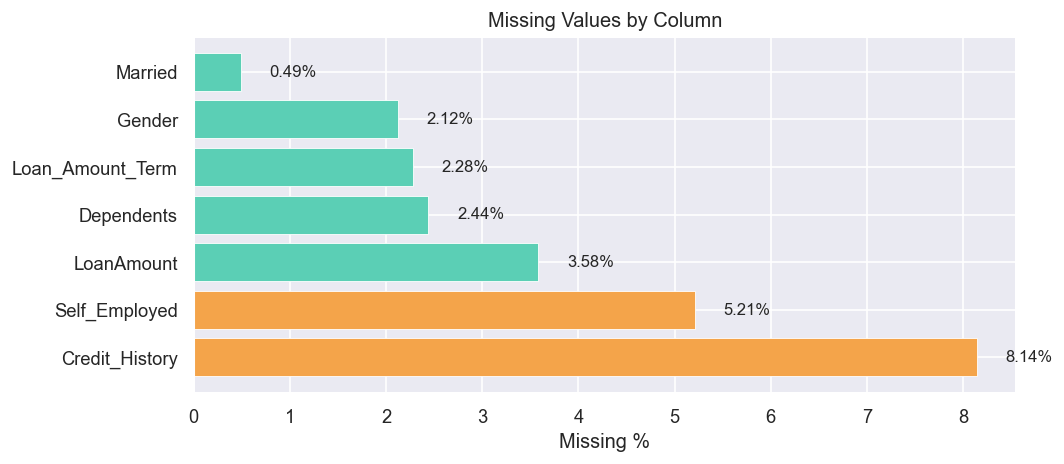

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('Columns with Missing Values:')
print(missing_df)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e05c5c' if x > 20 else '#f4a44a' if x > 5 else '#5bcfb5'
          for x in missing_df['Missing %']]
bars = ax.barh(missing_df.index, missing_df['Missing %'],
               color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

## Step 6 — Handle Missing Values

We now fill all missing values using the appropriate strategy for each column type.
After filling, we verify that no missing values remain in the dataset.

**Why median over mean for numerical columns?**
Loan amounts often have outliers (very high values). The median is not affected by extreme values, making it a safer fill choice.

**Why mode for categorical columns?**
For text-based columns like `Gender` or `Married`, the most frequent value is the most reasonable default assumption.

In [15]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include='object').columns
            if c not in ['Loan_ID', 'Loan_Status']]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
    print(f'  Filled [{col}] with median: {df[col].median()}')

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
    print(f'  Filled [{col}] with mode: "{df[col].mode()[0]}"')

# Double-check — force fill anything remaining
df.fillna(df.median(numeric_only=True), inplace=True)

print('\nTotal NaN remaining:', df.isnull().sum().sum())

  Filled [ApplicantIncome] with median: 3812.5
  Filled [CoapplicantIncome] with median: 1188.5
  Filled [LoanAmount] with median: 128.0
  Filled [Loan_Amount_Term] with median: 360.0
  Filled [Credit_History] with median: 1.0
  Filled [Gender] with mode: "Male"
  Filled [Married] with mode: "Yes"
  Filled [Dependents] with mode: "0"
  Filled [Education] with mode: "Graduate"
  Filled [Self_Employed] with mode: "No"
  Filled [Property_Area] with mode: "Semiurban"

Total NaN remaining: 63


## Step 7 — EDA: Loan Status Distribution

Before diving into features, we visualize the balance of our target variable.
An imbalanced dataset (e.g. 90% approved, 10% rejected) can mislead model accuracy scores.
Understanding this early helps us decide if we need resampling techniques later.

**What to observe:**
- If one class dominates significantly, the model may just predict the majority class
- A healthy dataset has a reasonable split between both classes
- We display both a count bar chart and a proportion pie chart side by side

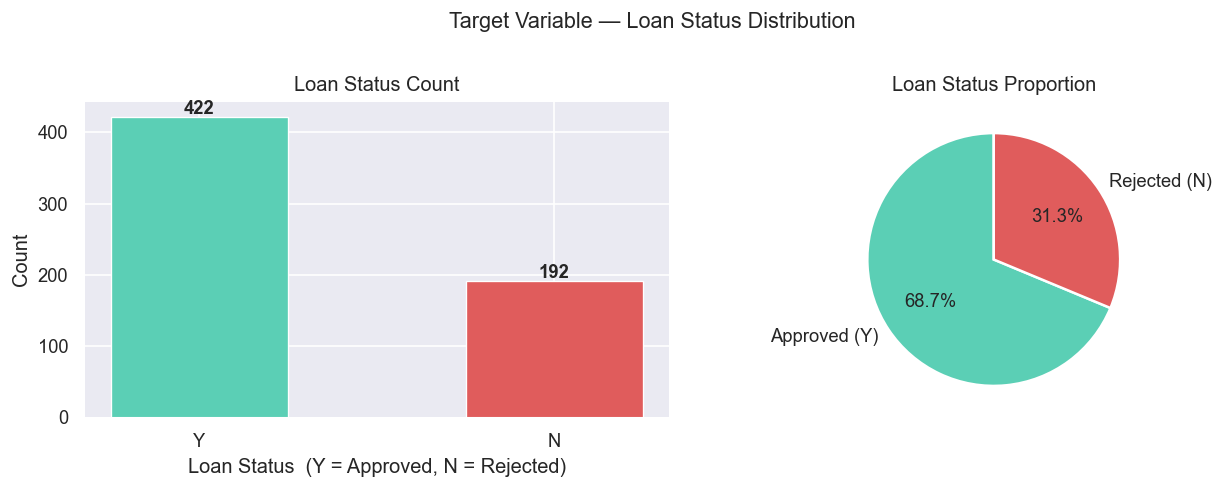

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['Loan_Status'].value_counts()
colors = ['#5bcfb5', '#e05c5c']

axes[0].bar(counts.index, counts.values, color=colors,
            edgecolor='white', linewidth=0.8, width=0.5)
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold')
axes[0].set_title('Loan Status Count')
axes[0].set_xlabel('Loan Status  (Y = Approved, N = Rejected)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Approved (Y)', 'Rejected (N)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Loan Status Proportion')

fig.suptitle('Target Variable — Loan Status Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 8 — EDA: Income and Loan Amount Distribution

We visualize applicant income, co-applicant income, and loan amount using overlapping histograms.
These are the most important numerical features — they directly influence whether a loan is risky.

**Key observations to look for:**
- Right-skewed distributions mean most people earn moderate amounts with a few very high earners
- High skewness in income suggests that log transformation may improve model performance
- Comparing income distributions by loan status shows whether higher income correlates with approval

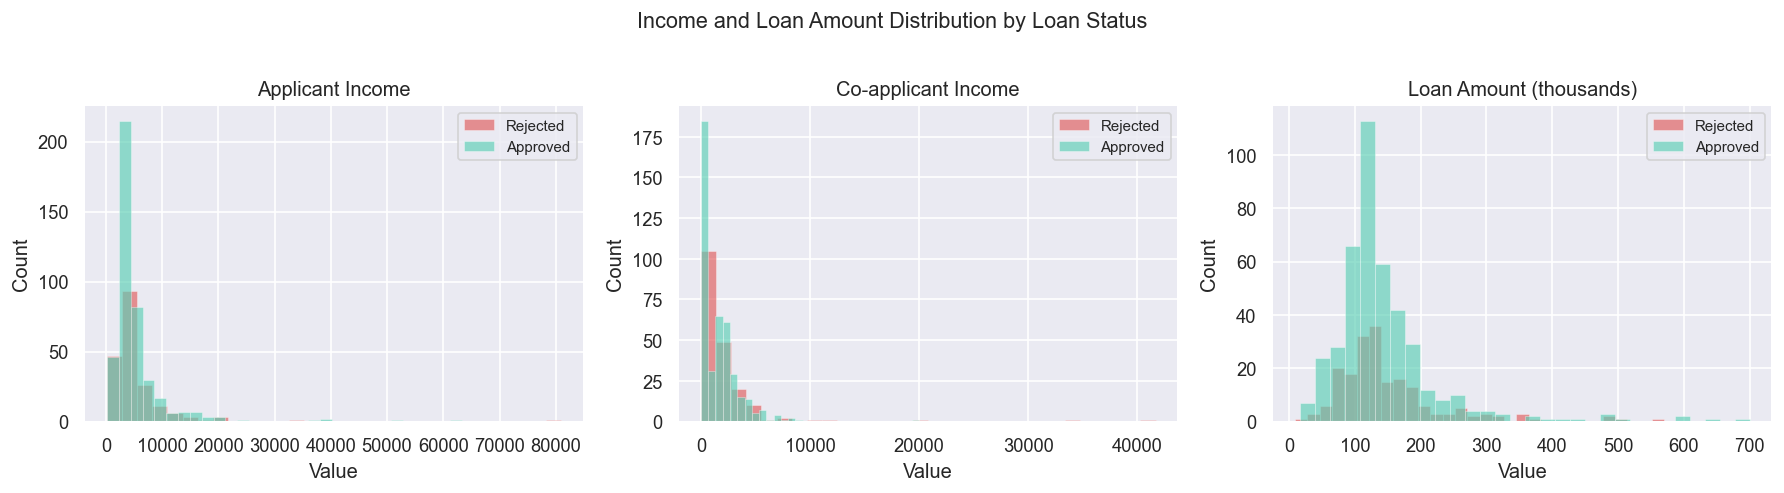

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
num_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
titles = ['Applicant Income', 'Co-applicant Income', 'Loan Amount (thousands)']
palette = {'Y': '#5bcfb5', 'N': '#e05c5c'}

for ax, feat, title in zip(axes, num_features, titles):
    for status, grp in df.groupby('Loan_Status'):
        ax.hist(grp[feat], bins=30, alpha=0.65,
                label=f'{"Approved" if status=="Y" else "Rejected"}',
                color=palette[status], edgecolor='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.suptitle('Income and Loan Amount Distribution by Loan Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 9 — EDA: Education, Employment and Credit History

We visualize how key categorical features relate to loan approval status using grouped bar charts.
These features are often strong predictors in credit risk models.

**What each feature tells us:**
- `Education` — graduates may have more stable income and higher approval rates
- `Self_Employed` — self-employed applicants may have irregular income, affecting approval
- `Credit_History` — the most critical feature; a bad credit history (0) almost always means rejection

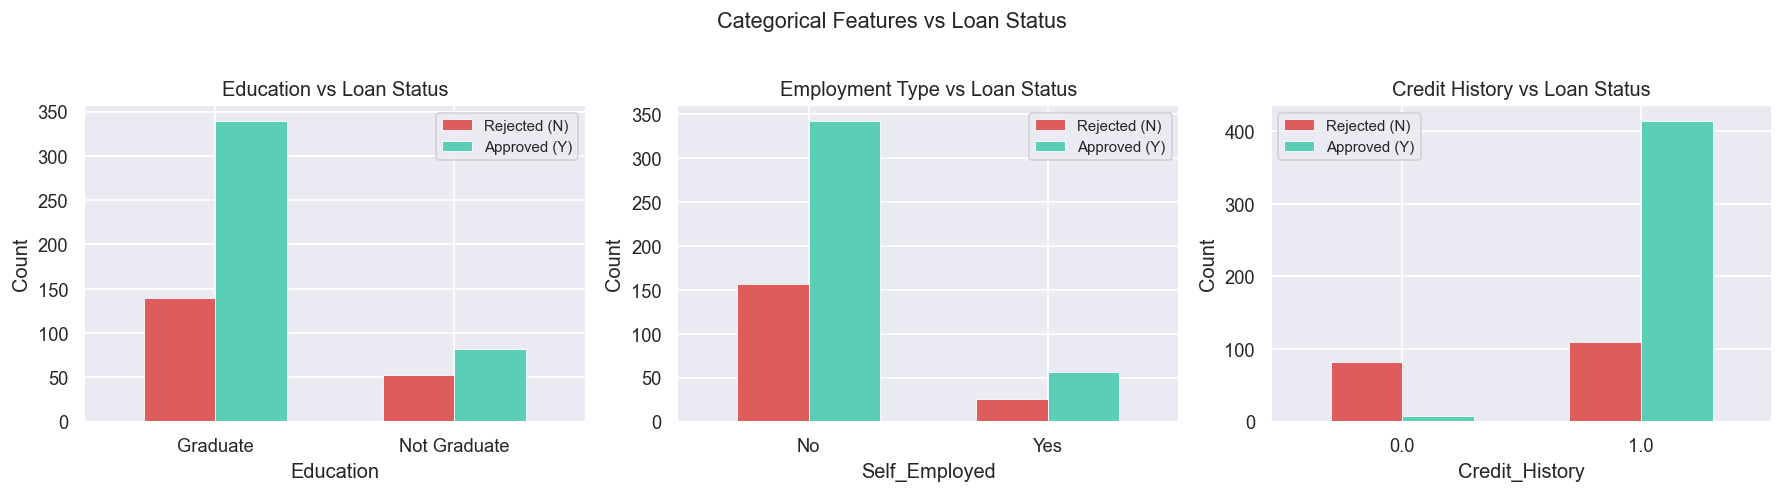

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cat_features = ['Education', 'Self_Employed', 'Credit_History']
titles = ['Education vs Loan Status',
          'Employment Type vs Loan Status',
          'Credit History vs Loan Status']

for ax, feat, title in zip(axes, cat_features, titles):
    ct = pd.crosstab(df[feat], df['Loan_Status'])
    ct.plot(kind='bar', ax=ax,
            color=['#e05c5c', '#5bcfb5'],
            edgecolor='white', linewidth=0.5, width=0.6)
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(['Rejected (N)', 'Approved (Y)'], fontsize=9)

fig.suptitle('Categorical Features vs Loan Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 10 — EDA: Loan Amount by Education and Property Area

Box plots let us compare the distribution of loan amounts across different categorical groups.
This reveals whether certain applicant groups tend to request larger or smaller loans.

**What to observe:**
- Do graduates request significantly higher loan amounts than non-graduates?
- Does property area (Urban, Semiurban, Rural) affect the loan amount requested?
- Are there notable outliers (dots beyond the whiskers) in any group?

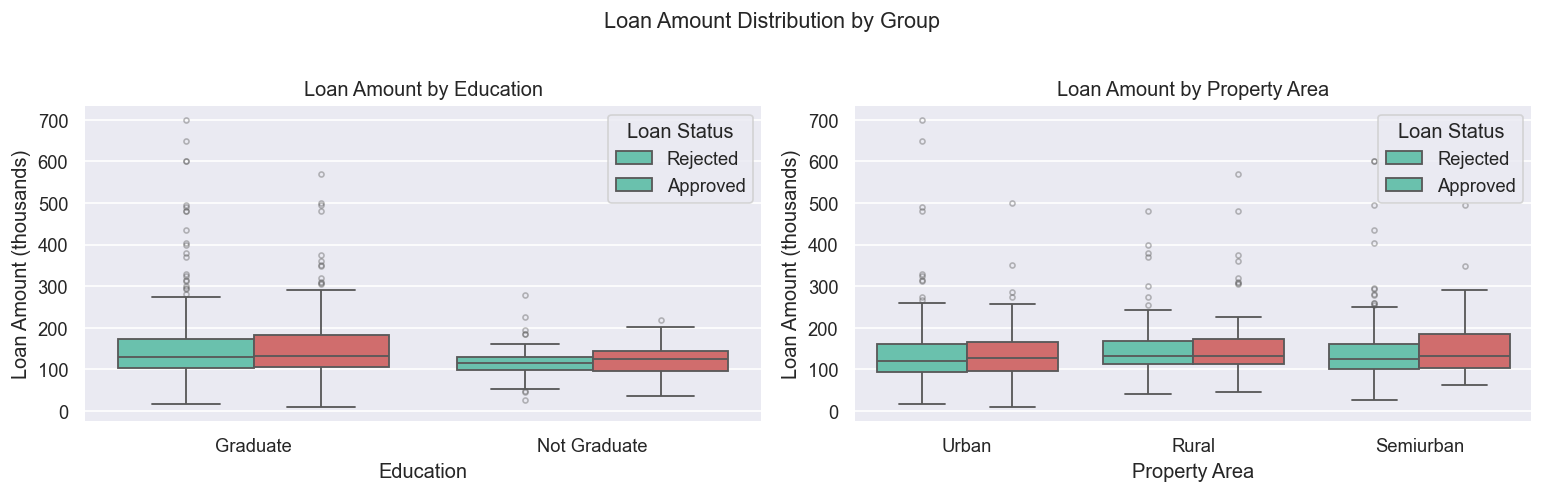

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {'Y': '#5bcfb5', 'N': '#e05c5c'}

sns.boxplot(
    data=df, x='Education', y='LoanAmount',
    hue='Loan_Status', palette=palette, ax=axes[0],
    linewidth=1.1, legend=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
axes[0].set_title('Loan Amount by Education')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Loan Amount (thousands)')
axes[0].legend(title='Loan Status', labels=['Rejected', 'Approved'])

sns.boxplot(
    data=df, x='Property_Area', y='LoanAmount',
    hue='Loan_Status', palette=palette, ax=axes[1],
    linewidth=1.1, legend=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
axes[1].set_title('Loan Amount by Property Area')
axes[1].set_xlabel('Property Area')
axes[1].set_ylabel('Loan Amount (thousands)')
axes[1].legend(title='Loan Status', labels=['Rejected', 'Approved'])

fig.suptitle('Loan Amount Distribution by Group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 11 — EDA: Correlation Heatmap

A correlation heatmap shows which numerical features are most related to each other.
This helps identify redundant features (high correlation = similar information) before modeling.

**Why this matters for machine learning:**
- Highly correlated input features can cause multicollinearity, which destabilizes Logistic Regression
- Features with high correlation to the target variable are the strongest predictors
- We encode `Loan_Status` to numeric (1/0) temporarily so it appears in the correlation matrix

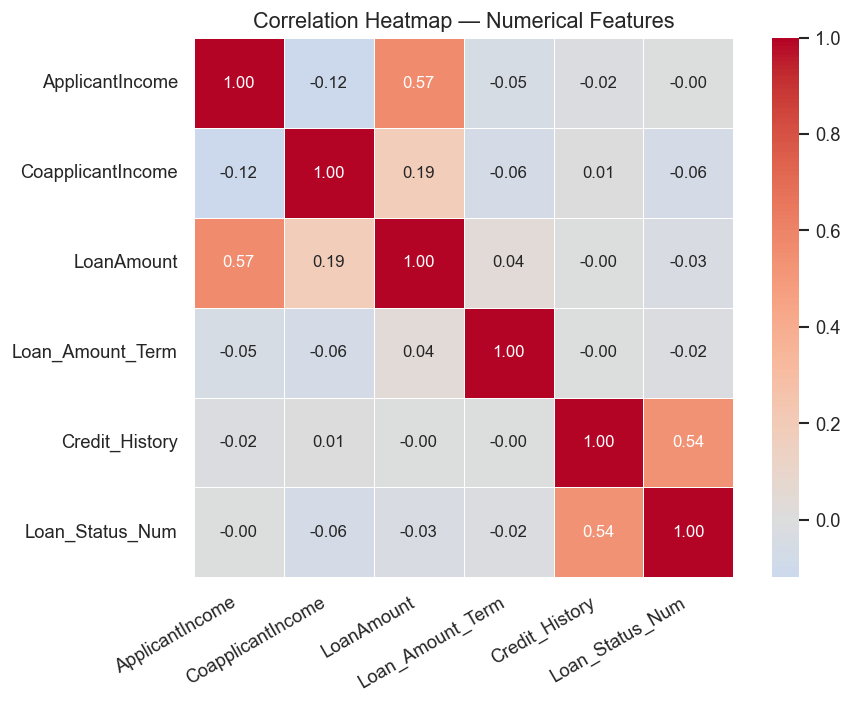

In [20]:
df_corr = df.copy()
df_corr['Loan_Status_Num'] = df_corr['Loan_Status'].map({'Y': 1, 'N': 0})
num_corr_cols = ['ApplicantIncome', 'CoapplicantIncome',
                 'LoanAmount', 'Loan_Amount_Term',
                 'Credit_History', 'Loan_Status_Num']
corr = df_corr[num_corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax, annot_kws={'size': 10}
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Step 12 — Feature Engineering and Encoding

Machine learning models only work with numbers — not text.
We use `LabelEncoder` to convert all categorical columns into numeric values.
We also drop `Loan_ID` since it is just an identifier with no predictive value.

**What LabelEncoder does:**
- Converts `Yes / No` to `1 / 0`
- Converts `Graduate / Not Graduate` to `1 / 0`
- Converts `Urban / Semiurban / Rural` to `2 / 1 / 0` (alphabetical order)

After encoding, every column is a number and the dataset is ready for model training.

In [21]:
df_model = df.drop(columns=['Loan_ID']).copy()
le = LabelEncoder()
encode_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in encode_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'  Encoded [{col}] — unique values: {df_model[col].unique()}')

print('\nSample after encoding:')
df_model.head()

  Encoded [Gender] — unique values: [1 0 2]
  Encoded [Married] — unique values: [0 1 2]
  Encoded [Dependents] — unique values: [0 1 2 3 4]
  Encoded [Education] — unique values: [0 1]
  Encoded [Self_Employed] — unique values: [0 1 2]
  Encoded [Property_Area] — unique values: [2 0 1]
  Encoded [Loan_Status] — unique values: [1 0]

Sample after encoding:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## Step 13 — Split Data into Train and Test Sets

We split the dataset into training data (80%) and testing data (20%).
The model learns patterns from the training set and is evaluated on the test set — data it has never seen.

**Key parameters:**
- `test_size=0.2` — 20% of data held out for testing
- `random_state=42` — ensures the same split every time for reproducibility
- `stratify=y` — keeps the same approved/rejected ratio in both train and test sets

In [22]:
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total samples   : {len(df_model)}')
print(f'Training samples: {len(X_train)} ({len(X_train)/len(df_model)*100:.0f}%)')
print(f'Testing samples : {len(X_test)} ({len(X_test)/len(df_model)*100:.0f}%)')
print(f'\nFeatures used   : {X.columns.tolist()}')

Total samples   : 614
Training samples: 491 (80%)
Testing samples : 123 (20%)

Features used   : ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


## Step 14 — Train Model 1: Logistic Regression

Logistic Regression is a linear model used for binary classification.
It estimates the probability of an applicant defaulting and classifies them as approved or rejected.
Despite its simplicity, it is a strong and interpretable baseline model for credit risk problems.

**How it works:**
- Finds a linear boundary that separates approved vs rejected applicants in feature space
- Outputs a probability between 0 and 1 — above 0.5 is classified as approved
- `max_iter=1000` gives the solver enough iterations to find the optimal boundary

In [23]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print('Logistic Regression Results')
print('=' * 40)
print(f'Accuracy : {lr_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred,
                             target_names=['Rejected (0)', 'Approved (1)']))

Logistic Regression Results
Accuracy : 86.18%

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.96      0.58      0.72        38
Approved (1)       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



## Step 16 — Confusion Matrix (Both Models)

A confusion matrix shows exactly where each model makes correct and incorrect predictions.
It breaks results into four categories: True Positives, True Negatives, False Positives, False Negatives.

**Why this matters more than accuracy alone:**
- A **False Negative** (approving someone who defaults) costs the bank real money
- A **False Positive** (rejecting someone creditworthy) means lost business
- Depending on the business priority, we may want to minimize one error type over the other

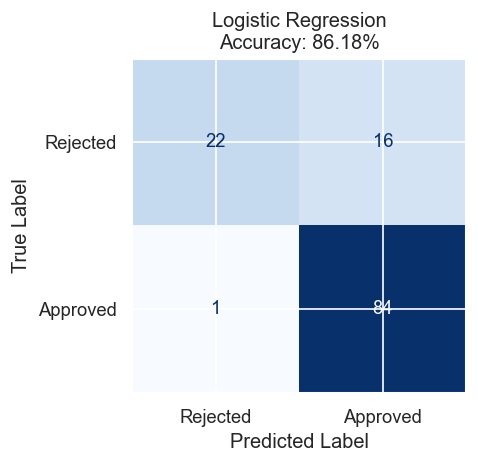

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rejected', 'Approved']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
ax.set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.2f}%')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## Step 19 — Model Comparison Summary

We bring together all evaluation results into a final comparison chart and table.
Accuracy alone is not enough — we compare Precision, Recall, and F1 Score to get the full picture.

**What each metric means:**
- **Accuracy** — overall percentage of correct predictions
- **Precision** — of all predicted approvals, how many were actually correct?
- **Recall** — of all actual approvals, how many did the model successfully catch?
- **F1 Score** — harmonic mean of precision and recall; best single metric for imbalanced data

Logistic Regression — Full Evaluation:
   Metric  Score
 Accuracy  86.18
Precision  84.00
   Recall  98.82
 F1 Score  90.81


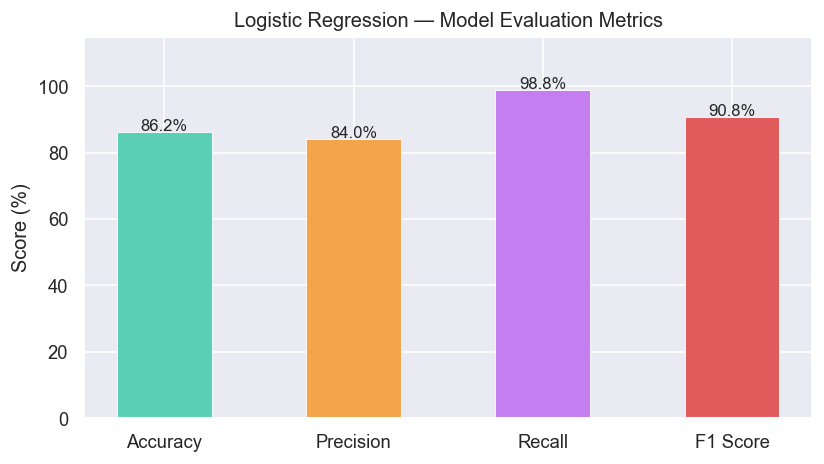

In [30]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [
        accuracy_score(y_test, lr_pred)  * 100,
        precision_score(y_test, lr_pred) * 100,
        recall_score(y_test, lr_pred)    * 100,
        f1_score(y_test, lr_pred)        * 100
    ]
}).round(2)

print('Logistic Regression — Full Evaluation:')
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results['Metric'], results['Score'],
              color=['#5bcfb5','#f4a44a','#c47ef0','#e05c5c'],
              edgecolor='white', linewidth=0.5, width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Logistic Regression — Model Evaluation Metrics')
plt.tight_layout()
plt.show()

## Step 20 — Final Conclusions

A clean summary of everything we completed.
It identifies the best-performing model and highlights the most important finding from the analysis.

**Final takeaways:**
- EDA confirmed that `Credit_History` is by far the strongest predictor of loan approval
- Logistic Regression offers better interpretability
- The confusion matrix revealed where each model fails — critical information for real-world deployment

In [31]:
print('=' * 55)
print('  FINAL SUMMARY — Credit Risk Prediction')
print('=' * 55)
print(f'  Dataset Size              : {len(df)} samples')
print(f'  Features Used             : {X.shape[1]}')
print(f'  Train / Test Split        : 80% / 20%')
print(f'  Missing Values Handled    : Median + Mode strategy')
print()
print(f'  Model                     : Logistic Regression')
print(f'  Accuracy                  : {lr_acc*100:.2f}%')
print(f'  Precision                 : {precision_score(y_test, lr_pred)*100:.2f}%')
print(f'  Recall                    : {recall_score(y_test, lr_pred)*100:.2f}%')
print(f'  F1 Score                  : {f1_score(y_test, lr_pred)*100:.2f}%')
print()
print('  Key Finding:')
print('  Credit_History is the single most important')
print('  predictor — applicants with no credit history')
print('  are overwhelmingly rejected by the model.')
print('=' * 55)

  FINAL SUMMARY — Credit Risk Prediction
  Dataset Size              : 614 samples
  Features Used             : 11
  Train / Test Split        : 80% / 20%
  Missing Values Handled    : Median + Mode strategy

  Model                     : Logistic Regression
  Accuracy                  : 86.18%
  Precision                 : 84.00%
  Recall                    : 98.82%
  F1 Score                  : 90.81%

  Key Finding:
  Credit_History is the single most important
  predictor — applicants with no credit history
  are overwhelmingly rejected by the model.
